In [15]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass

trapz = np.trapz

c_kms = 299_792.458
def kms_to_c(v_kms): return v_kms / c_kms
def c_to_kms(v_c):   return v_c * c_kms

In [16]:
# geometry
R_sun_cm = 6.957e10
AU_cm    = 1.495978707e13
geom_dilution = (np.pi * (4.0*R_sun_cm)**2) / (4.0*np.pi * AU_cm**2)  # π(4R☉)^2 / (4π AU^2)

# escape speeds
v_esc_core_kms = 1380.0
v_esc_surf_kms = 617.0
v_esc_AU_kms   = 42.1       # solar escape at 1 AU
v_esc_AU       = kms_to_c(v_esc_AU_kms)

def vesc_of_r(r_cm):
    """Smooth interpolation between core and surface escape speeds."""
    x = r_cm / R_sun_cm
    v_kms = v_esc_core_kms*(1.0 - x**2) + v_esc_surf_kms*(x**2)
    return kms_to_c(v_kms)

# simple electron profiles
n_e0   = 6.0e25           # cm^-3 (central value)
T0_keV = 1.3              # keV   (central-ish value)

def n_e_of_r(r_cm):
    x = r_cm / R_sun_cm
    return n_e0 * (1.0 - x*x)**2

def T_of_r(r_cm):
    x = r_cm / R_sun_cm
    return T0_keV * (0.7 + 0.3*(1.0 - x*x))

In [17]:
# %%
m_e_keV   = 511.0
rho_DM_keVcm3 = 0.3 * 1e6     # 0.3 GeV/cm^3 → keV/cm^3
vbar_halo     = kms_to_c(220.0)  # <speed> prefactor used for Φ_halo (can be refined)

# Sun-frame DM distribution params (shifted, truncated Maxwellian)
v0_kms        = 220.0
v_sun_kms     = 232.0
v_esc_gal_kms = 544.0

v0        = kms_to_c(v0_kms)
v_sun     = kms_to_c(v_sun_kms)
v_esc_gal = kms_to_c(v_esc_gal_kms)

def Nesc(v0, vesc):
    z = vesc / (v0 + 1e-300)
    return np.math.erf(z) - (2.0/np.sqrt(np.pi))*z*np.exp(-z*z)

N_esc = Nesc(v0, v_esc_gal)   # normalization of the truncated Maxwellian

/tmp/ipykernel_745/395611524.py:17: DeprecationWarning: `np.math` is a deprecated alias for the standard library `math` module (Deprecated Numpy 1.25). Replace usages of `np.math` with `math`
  return np.math.erf(z) - (2.0/np.sqrt(np.pi))*z*np.exp(-z*z)


In [18]:
# %%
def mu_red(m1_keV, m2_keV):
    return (m1_keV*m2_keV)/(m1_keV + m2_keV + 1e-300)

def s_MB(T_keV, m_keV):
    """Most probable speed for a Maxwellian: u_e = sqrt(2T/m)."""
    return np.sqrt(2.0*T_keV/m_keV)

def f_MB_3D(u, s):
    """Normalized 3D Maxwell-Boltzmann pdf: ∫ d^3u f = 1."""
    return (1.0/(np.pi**1.5 * s**3)) * np.exp(-(u*u)/(s*s))

def w_rel(vchi, u, mu):
    """Relative speed between DM at speed vchi and electron speed u with cosθ = mu."""
    return np.sqrt(vchi*vchi + u*u - 2.0*vchi*u*mu)

def w_min_thresh(mchi_keV, delta_keV):
    """Endothermic threshold on relative speed."""
    mu = mu_red(mchi_keV, m_e_keV)
    return np.sqrt(2.0*delta_keV / (mu + 1e-300))

In [19]:
# %%
def f_DM_weight_mu(vinf, mu):
    """
    Angular factor: exp(-( |v∞ + v_⊙|^2 )/v0^2 ) with truncation.
    Returns the exponent*Θ(...) (no normalization), shape compatible with mu.
    """
    # |v∞ + v_⊙|^2 = v∞^2 + v_⊙^2 + 2 v∞ v_⊙ μ
    s2 = vinf*vinf + v_sun*v_sun + 2.0*vinf*v_sun*mu
    cond = s2 <= (v_esc_gal*v_esc_gal)
    if np.isscalar(mu):
        return np.exp(-s2/(v0*v0)) if cond else 0.0
    out = np.exp(-s2/(v0*v0))
    out[~cond] = 0.0
    return out

def DM_weight_vinf(vinf, mu_grid):
    """
    Full angular weight W(v∞) = 2π v∞^2 * ∫ dμ f^⊙(v∞,μ) / [N_esc (π v0^2)^{3/2}].
    This is normalized so that ∫ d^3 v∞ f^⊙ = 1.
    """
    I_mu = trapz(f_DM_weight_mu(vinf, mu_grid), mu_grid)
    pref = 2.0*np.pi * (vinf*vinf) / (N_esc * (np.pi*v0*v0)**1.5)
    return pref * I_mu

In [20]:
# %%
def kernel_elastic(k1, q, costh, T_keV, mchi_keV):
    term = (m_e_keV/(2.0*mchi_keV))*(2.0*k1*costh + q) + 0.5*q
    return q * np.exp(-(term*term)/(2.0*m_e_keV*T_keV))

def kernel_inelastic(k1, q, costh, T_keV, mchi_keV, delta_keV):
    term = (m_e_keV/(2.0*mchi_keV))*(2.0*k1*costh + q) + 0.5*q + (m_e_keV*delta_keV)/(q + 1e-300)
    return q * np.exp(-(term*term)/(2.0*m_e_keV*T_keV))

def dGamma_dvf_raw(r_cm, v_f, vchi, mchi_keV, kernel_fn, qN=240, **kernel_kwargs):
    """Project ANPPR kernel onto the final DM speed v_f (in the plasma frame)."""
    if v_f <= 0.0:
        return 0.0
    T  = T_of_r(r_cm)
    k1 = mchi_keV * vchi

    qmin = abs(k1 - mchi_keV*v_f)
    qmax = (k1 + mchi_keV*v_f)
    if qmax <= 0.0:
        return 0.0

    q = np.linspace(qmin, qmax, qN)
    with np.errstate(divide='ignore', invalid='ignore'):
        costh = (k1*k1 + q*q - (mchi_keV*v_f)**2) / (2.0*k1*q)
    mask = (q>0) & (costh>=-1.0) & (costh<=1.0)
    if not np.any(mask):
        return 0.0
    q, costh = q[mask], costh[mask]
    kern = kernel_fn(k1, q, costh, T, mchi_keV, **kernel_kwargs)
    integral_q = trapz(kern, q)
    pref = (mchi_keV*mchi_keV * v_f) / (k1 + 1e-300)
    return pref * integral_q

In [21]:
# %%
def Gamma_total_elastic(r_cm, mchi_keV, vchi, sigma_tot_cm2, uN=70, muN=70):
    ne = n_e_of_r(r_cm)
    s  = s_MB(T_of_r(r_cm), m_e_keV)
    u_grid  = np.linspace(0.0, 6.0*s, uN)
    mu_grid = np.linspace(-1.0, 1.0, muN)
    total = 0.0
    for u in u_grid:
        f3 = f_MB_3D(u, s)
        w  = w_rel(vchi, u, mu_grid)
        total += (2.0*np.pi) * f3 * u*u * trapz(w, mu_grid)
    return sigma_tot_cm2 * ne * total

def Gamma_total_inelastic(r_cm, mchi_keV, vchi, sigma_tot_cm2, delta_keV, uN=70, muN=70):
    ne = n_e_of_r(r_cm)
    s  = s_MB(T_of_r(r_cm), m_e_keV)
    wmin = w_min_thresh(mchi_keV, delta_keV)
    u_grid  = np.linspace(0.0, 6.0*s, uN)
    mu_grid = np.linspace(-1.0, 1.0, muN)
    total = 0.0
    for u in u_grid:
        f3 = f_MB_3D(u, s)
        w  = w_rel(vchi, u, mu_grid)
        total += (2.0*np.pi) * f3 * u*u * trapz(w*(w>=wmin), mu_grid)
    return sigma_tot_cm2 * ne * total

In [22]:
# %%
@dataclass
class RadialSlice:
    r: float
    vesc: float
    vF_grid: np.ndarray
    dGdvF: np.ndarray  # this is ⟨(1/vχ) dΓ/dv_f⟩_DM already × σ_tot × n_e(r)

def normalized_spectrum_at_r_elastic(r_cm, mchi_keV, sigma_tot_cm2,
                                     vF_max_kms=2200.0, NvF=200, qN=200,
                                     Nvinf=70, Nmu=80):
    vF_grid   = kms_to_c(np.linspace(1.0, vF_max_kms, NvF))
    vinf_grid = kms_to_c(np.linspace(0.0, v_esc_gal_kms + v_sun_kms, Nvinf))
    mu_grid   = np.linspace(-1.0, 1.0, Nmu)

    W   = np.array([DM_weight_vinf(vinf, mu_grid) for vinf in vinf_grid])  # normalized DM weights
    vch = np.sqrt(vinf_grid*vinf_grid + vesc_of_r(r_cm)**2)                # local speeds

    raw = np.zeros_like(vF_grid)
    for j, vF in enumerate(vF_grid):
        contrib = np.array([
            (1.0/(vch[i] + 1e-300)) * dGamma_dvf_raw(r_cm, vF, vch[i], mchi_keV,
                                                     kernel_elastic, qN=qN)
            for i in range(Nvinf)
        ])
        raw[j] = trapz(W*contrib, vinf_grid)

    # normalization target: ⟨Γ_tot / vχ⟩
    G_over_v = np.array([
        Gamma_total_elastic(r_cm, mchi_keV, vch[i], sigma_tot_cm2)/(vch[i] + 1e-300)
        for i in range(Nvinf)
    ])
    target = trapz(W*G_over_v, vinf_grid)

    integ_raw = trapz(raw, vF_grid)
    N = 0.0 if integ_raw<=0 else target/integ_raw
    return vF_grid, N*raw

def normalized_spectrum_at_r_inelastic(r_cm, mchi_keV, sigma_tot_cm2, delta_keV,
                                       vF_max_kms=2200.0, NvF=200, qN=200,
                                       Nvinf=70, Nmu=80):
    vF_grid   = kms_to_c(np.linspace(1.0, vF_max_kms, NvF))
    vinf_grid = kms_to_c(np.linspace(0.0, v_esc_gal_kms + v_sun_kms, Nvinf))
    mu_grid   = np.linspace(-1.0, 1.0, Nmu)

    W   = np.array([DM_weight_vinf(vinf, mu_grid) for vinf in vinf_grid])
    vch = np.sqrt(vinf_grid*vinf_grid + vesc_of_r(r_cm)**2)

    raw = np.zeros_like(vF_grid)
    for j, vF in enumerate(vF_grid):
        contrib = np.array([
            (1.0/(vch[i] + 1e-300)) * dGamma_dvf_raw(r_cm, vF, vch[i], mchi_keV,
                                                     kernel_inelastic, qN=qN, delta_keV=delta_keV)
            for i in range(Nvinf)
        ])
        raw[j] = trapz(W*contrib, vinf_grid)

    G_over_v = np.array([
        Gamma_total_inelastic(r_cm, mchi_keV, vch[i], sigma_tot_cm2, delta_keV)/(vch[i] + 1e-300)
        for i in range(Nvinf)
    ])
    target = trapz(W*G_over_v, vinf_grid)

    integ_raw = trapz(raw, vF_grid)
    N = 0.0 if integ_raw<=0 else target/integ_raw
    return vF_grid, N*raw

In [23]:
# %%
def build_radial_cache(mchi_keV, sigma_tot_cm2, Nr=40,
                       mode="elastic", delta_keV=0.0,
                       vF_max_kms=2200.0, NvF=200, qN=200,
                       Nvinf=70, Nmu=80):
    r_grid = np.linspace(0.0, R_sun_cm, Nr)
    cache = []
    for r in r_grid:
        if mode == "elastic":
            vF_grid, dGdvF = normalized_spectrum_at_r_elastic(
                r, mchi_keV, sigma_tot_cm2,
                vF_max_kms=vF_max_kms, NvF=NvF, qN=qN,
                Nvinf=Nvinf, Nmu=Nmu
            )
        else:
            vF_grid, dGdvF = normalized_spectrum_at_r_inelastic(
                r, mchi_keV, sigma_tot_cm2, delta_keV,
                vF_max_kms=vF_max_kms, NvF=NvF, qN=qN,
                Nvinf=Nvinf, Nmu=Nmu
            )
        cache.append(RadialSlice(r=r, vesc=vesc_of_r(r), vF_grid=vF_grid, dGdvF=dGdvF))
    return cache

def spectrum_from_cache(cache, mchi_keV,
                        vE_min_kms=10.0, vE_max_kms=1200.0, NvE=160,
                        chord_avg=True):
    vE = kms_to_c(np.linspace(vE_min_kms, vE_max_kms, NvE))
    E  = 0.5*mchi_keV*vE**2

    # upstream number flux at the Sun (simple prefactor; can be refined)
    Phi_halo = (rho_DM_keVcm3/(mchi_keV + 1e-300)) * vbar_halo

    dr   = (R_sun_cm / max(len(cache),1))
    path = 2.0*dr if chord_avg else dr

    P_of_E = np.zeros_like(vE)
    for sl in cache:
        # escape mapping to 1 AU (subtract v_esc at 1 AU)
        vF = np.sqrt(np.maximum(0.0, vE*vE + sl.vesc*sl.vesc - v_esc_AU*v_esc_AU))
        mask = vF > sl.vesc
        if not np.any(mask):
            continue
        dG_by_v = np.interp(vF[mask], sl.vF_grid, sl.dGdvF, left=0.0, right=0.0)
        # Jacobian dvF→dEχ: mχ vE / vF; collected to the form used below:
        P_of_E[mask] += path * (vF[mask]/(mchi_keV * vE[mask]**2)) * dG_by_v

    dPhi_dE = Phi_halo * geom_dilution * P_of_E
    return E, dPhi_dE

In [24]:
# %%
sigma_tot   = 4.382e-28         # cm^2  (contact χ–e)
delta_keV   = 3.7           # inelastic splitting (set 0 for elastic)
masses_keV  = [3.7e3, 1.0e4, 3.0e4]           # 3.7, 10, 30 MeV examples
m_scan_keV  = np.geomspace(2.0e3, 5.0e4, 15)  # for total flux scans

# grids (tune for speed/accuracy)
Nr, NvF, qN, Nvinf, Nmu = 40, 200, 200, 70, 80
vE_min_kms, vE_max_kms, NvE = 10.0, 1200.0, 160
vF_max_kms = 2200.0

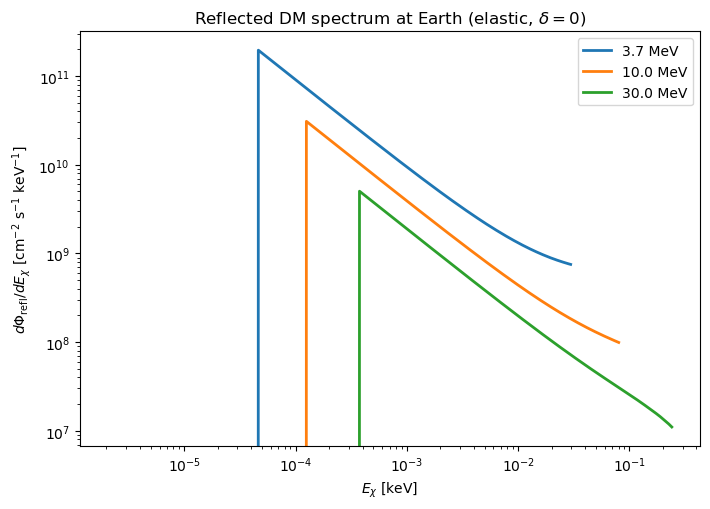

In [25]:
# %%
plt.figure(figsize=(7.2,5.2))
for mchi in masses_keV:
    cache = build_radial_cache(mchi, sigma_tot, Nr=Nr, mode="elastic",
                               vF_max_kms=vF_max_kms, NvF=NvF, qN=qN,
                               Nvinf=Nvinf, Nmu=Nmu)
    E, F = spectrum_from_cache(cache, mchi,
                               vE_min_kms=vE_min_kms, vE_max_kms=vE_max_kms, NvE=NvE)
    plt.loglog(E, F, lw=2, label=f"{mchi/1e3:.1f} MeV")
plt.xlabel(r"$E_\chi$ [keV]")
plt.ylabel(r"$d\Phi_{\rm refl}/dE_\chi$ [cm$^{-2}$ s$^{-1}$ keV$^{-1}$]")
plt.title(r"Reflected DM spectrum at Earth (elastic, $\delta=0$)")
plt.legend(); plt.tight_layout(); plt.show()

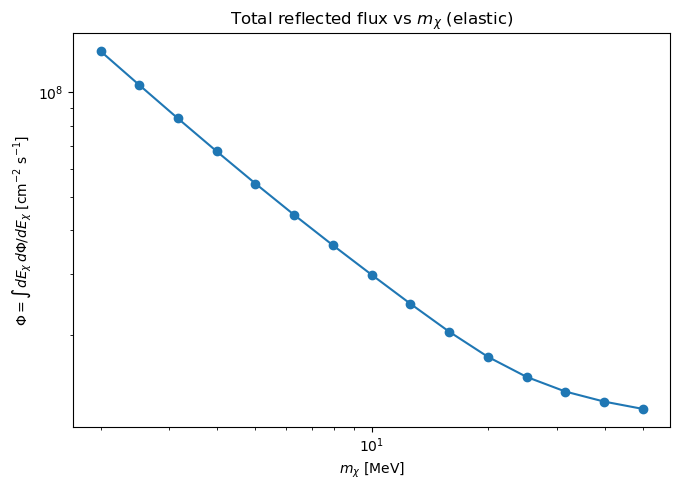

In [26]:
# %%
F_tot_el = []
for mchi in m_scan_keV:
    cache = build_radial_cache(mchi, sigma_tot, Nr=Nr, mode="elastic",
                               vF_max_kms=vF_max_kms, NvF=NvF, qN=qN,
                               Nvinf=Nvinf, Nmu=Nmu)
    E, F = spectrum_from_cache(cache, mchi,
                               vE_min_kms=vE_min_kms, vE_max_kms=vE_max_kms, NvE=NvE)
    F_tot_el.append(trapz(F, E))
F_tot_el = np.array(F_tot_el)

plt.figure(figsize=(6.9,5.0))
plt.loglog(m_scan_keV/1e3, F_tot_el, marker='o')
plt.xlabel(r"$m_\chi$ [MeV]")
plt.ylabel(r"$\Phi=\int dE_\chi\, d\Phi/dE_\chi$ [cm$^{-2}$ s$^{-1}$]")
plt.title("Total reflected flux vs $m_\\chi$ (elastic)")
plt.tight_layout(); plt.show()

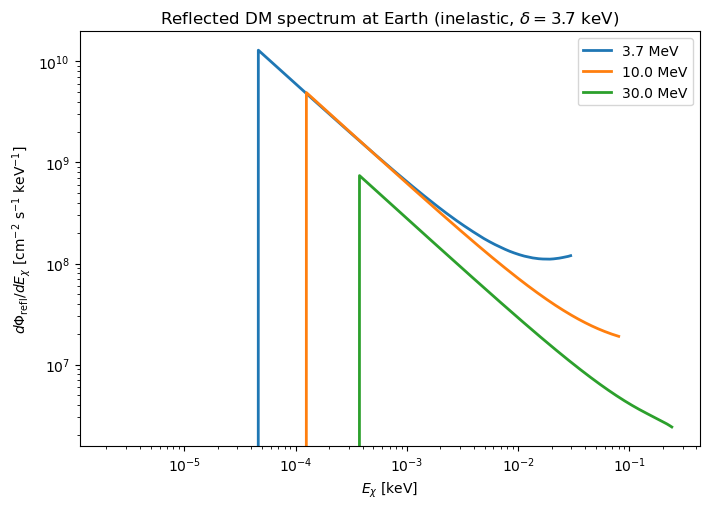

In [27]:
# %%
plt.figure(figsize=(7.2,5.2))
for mchi in masses_keV:
    cache = build_radial_cache(mchi, sigma_tot, Nr=Nr, mode="inelastic", delta_keV=delta_keV,
                               vF_max_kms=vF_max_kms, NvF=NvF, qN=qN,
                               Nvinf=Nvinf, Nmu=Nmu)
    E, F = spectrum_from_cache(cache, mchi,
                               vE_min_kms=vE_min_kms, vE_max_kms=vE_max_kms, NvE=NvE)
    plt.loglog(E, F, lw=2, label=f"{mchi/1e3:.1f} MeV")
plt.xlabel(r"$E_\chi$ [keV]")
plt.ylabel(r"$d\Phi_{\rm refl}/dE_\chi$ [cm$^{-2}$ s$^{-1}$ keV$^{-1}$]")
plt.title(fr"Reflected DM spectrum at Earth (inelastic, $\delta={delta_keV}$ keV)")
plt.legend(); plt.tight_layout(); plt.show()

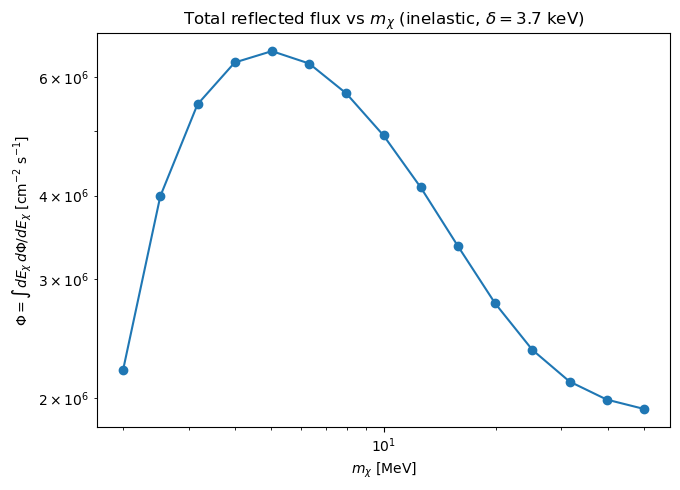

In [28]:
# %%
F_tot_in = []
for mchi in m_scan_keV:
    cache = build_radial_cache(mchi, sigma_tot, Nr=Nr, mode="inelastic", delta_keV=delta_keV,
                               vF_max_kms=vF_max_kms, NvF=NvF, qN=qN,
                               Nvinf=Nvinf, Nmu=Nmu)
    E, F = spectrum_from_cache(cache, mchi,
                               vE_min_kms=vE_min_kms, vE_max_kms=vE_max_kms, NvE=NvE)
    F_tot_in.append(trapz(F, E))
F_tot_in = np.array(F_tot_in)

plt.figure(figsize=(6.9,5.0))
plt.loglog(m_scan_keV/1e3, F_tot_in, marker='o')
plt.xlabel(r"$m_\chi$ [MeV]")
plt.ylabel(r"$\Phi=\int dE_\chi\, d\Phi/dE_\chi$ [cm$^{-2}$ s$^{-1}$]")
plt.title(fr"Total reflected flux vs $m_\chi$ (inelastic, $\delta={delta_keV}$ keV)")
plt.tight_layout(); plt.show()

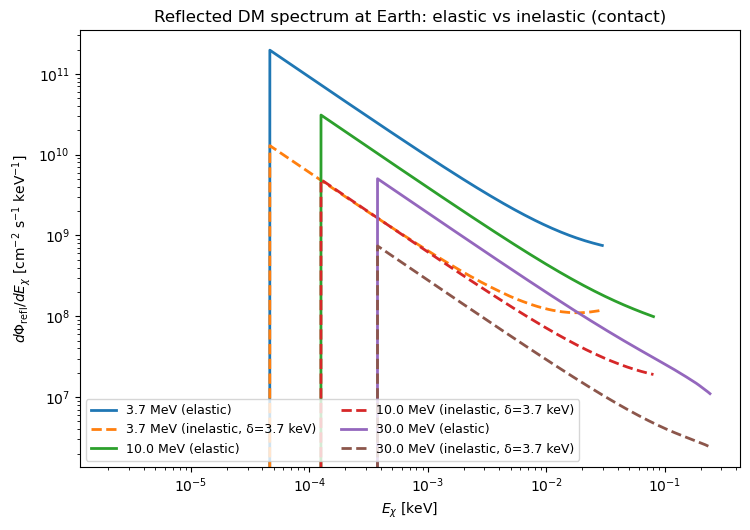

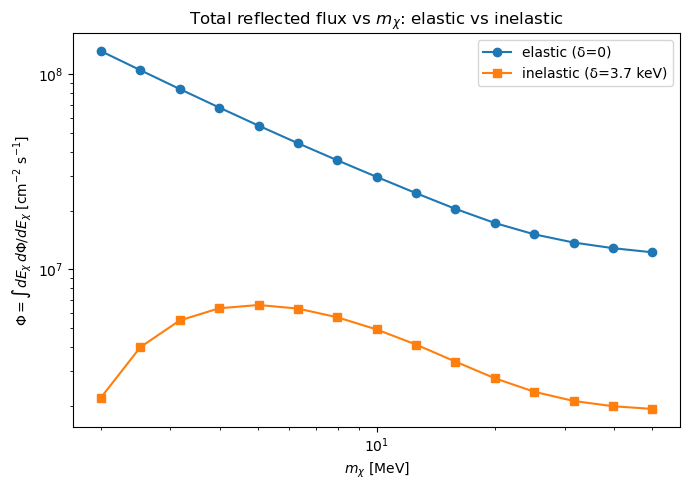

In [29]:
# %%
plt.figure(figsize=(7.6,5.4))
for mchi in masses_keV:
    cache_el = build_radial_cache(mchi, sigma_tot, Nr=Nr, mode="elastic",
                                  vF_max_kms=vF_max_kms, NvF=NvF, qN=qN,
                                  Nvinf=Nvinf, Nmu=Nmu)
    E_el, F_el = spectrum_from_cache(cache_el, mchi,
                                     vE_min_kms=vE_min_kms, vE_max_kms=vE_max_kms, NvE=NvE)
    cache_in = build_radial_cache(mchi, sigma_tot, Nr=Nr, mode="inelastic", delta_keV=delta_keV,
                                  vF_max_kms=vF_max_kms, NvF=NvF, qN=qN,
                                  Nvinf=Nvinf, Nmu=Nmu)
    E_in, F_in = spectrum_from_cache(cache_in, mchi,
                                     vE_min_kms=vE_min_kms, vE_max_kms=vE_max_kms, NvE=NvE)

    lab = f"{mchi/1e3:.1f} MeV"
    plt.loglog(E_el, F_el, lw=2, label=lab+" (elastic)")
    plt.loglog(E_in, F_in, lw=2, ls="--", label=lab+f" (inelastic, δ={delta_keV:g} keV)")

plt.xlabel(r"$E_\chi$ [keV]")
plt.ylabel(r"$d\Phi_{\rm refl}/dE_\chi$ [cm$^{-2}$ s$^{-1}$ keV$^{-1}$]")
plt.title(r"Reflected DM spectrum at Earth: elastic vs inelastic (contact)")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

plt.figure(figsize=(7.0,5.0))
plt.loglog(m_scan_keV/1e3, F_tot_el, marker='o', label="elastic (δ=0)")
plt.loglog(m_scan_keV/1e3, F_tot_in, marker='s', label=f"inelastic (δ={delta_keV:g} keV)")
plt.xlabel(r"$m_\chi$ [MeV]")
plt.ylabel(r"$\Phi=\int dE_\chi\, d\Phi/dE_\chi$ [cm$^{-2}$ s$^{-1}$]")
plt.title("Total reflected flux vs $m_\\chi$: elastic vs inelastic")
plt.legend(); plt.tight_layout(); plt.show()

In [33]:
mchi_keV      = 3.7e3
me_keV        = 511.0
Tcore_keV     = 1.1
ne_core_cm3   = 2.0e25
Vcore_cm3     = 2.2e31
AU_cm         = 1.495978707e13
rho0_GeVcm3   = 0.3
v0_kms        = 220.0
vesc_core_kms = 1500.0

# Model normalization
sigma_e_cm2   = 4.382e-37

mchi_GeV      = mchi_keV * 1e-6
mu_keV        = (mchi_keV*me_keV)/(mchi_keV + me_keV)
n0_cm3        = rho0_GeVcm3 / mchi_GeV
nchi_core_cm3 = n0_cm3 * (vesc_core_kms / v0_kms)  


def vmin_of_K(K_keV, mchi_keV, mu_keV, delta_keV):
    K = np.asarray(K_keV)
    return ((mchi_keV*K) / mu_keV + delta_keV) / np.sqrt(2.0 * mchi_keV * K + 1e-300)

def avg_factor_core(K_keV, delta_keV):
    vm = vmin_of_K(K_keV, mchi_keV, mu_keV, delta_keV)
    return np.sqrt(2.0/np.pi) * np.sqrt(me_keV/Tcore_keV) * np.exp(- me_keV*vm**2/(2.0*Tcore_keV))

def dsigmadK_avg_core(K_keV, delta_keV):
    return sigma_e_cm2 * mchi_keV / (2.0*mu_keV**2) * avg_factor_core(K_keV, delta_keV)

def flux_differential_core(K_keV, delta_keV):
    geom = ne_core_cm3 * nchi_core_cm3 * Vcore_cm3 / (4.0*np.pi*AU_cm**2)
    return geom * dsigmadK_avg_core(K_keV, delta_keV) 

In [34]:
def nchi_of_r_factory(mchi_keV, v0_kms=220.0, rho0_GeVcm3=rho0_GeVcm3):
    n0 = rho0_GeVcm3 / (mchi_keV*1e-6 + 1e-300)                     # [cm^-3]
    v0 = (v0_kms / 299_792.458)                                     # in c
    def n_of_r(r_cm): return n0 * (vesc_of_r(r_cm) / (v0 + 1e-300))
    return np.vectorize(n_of_r)

def dphi_dKstar_full(Kstar_keV, mchi_keV, delta_keV, sigma_e_cm2, Nr=240):
    # grids & solar profiles
    r    = np.linspace(0.0, R_sun_cm, Nr)
    ne   = n_e_of_r(r)
    T    = T_of_r(r)
    nchi = nchi_of_r_factory(mchi_keV)(r)

    # reduced mass and v_min(K_*)
    mu   = (mchi_keV*me_keV)/(mchi_keV + me_keV)
    K    = np.asarray(Kstar_keV)
    vmin = ((mchi_keV*K)/mu + delta_keV) / np.sqrt(2.0*mchi_keV*K + 1e-300)

    # Maxwell–Boltzmann average at local T(r)
    avg  = np.sqrt(2.0/np.pi) * np.sqrt(me_keV/T) * np.exp(- me_keV*vmin*vmin/(2.0*T))

    # prefactor σ_e mχ / (2 μ^2)
    pref = sigma_e_cm2 * mchi_keV / (2.0*mu*mu)

    # radial integral and geometric dilution
    integrand = 4.0*np.pi * r*r * ne * nchi * pref * avg      # [keV^-1 s^-1]
    return trapz(integrand, r) / (4.0*np.pi*AU_cm**2)         # [keV^-1 cm^-2 s^-1]


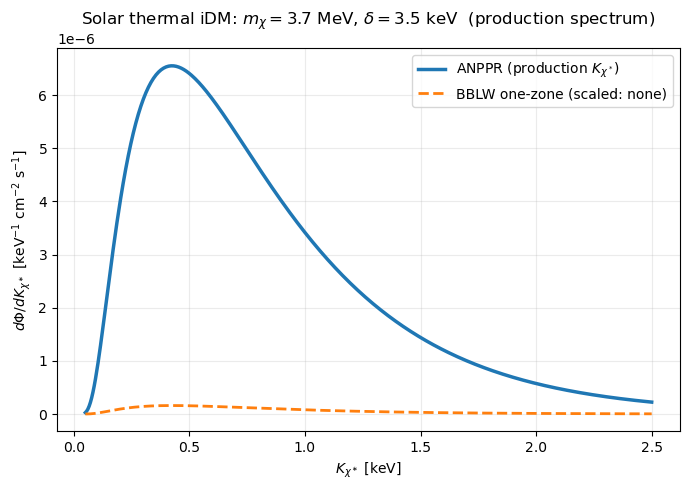

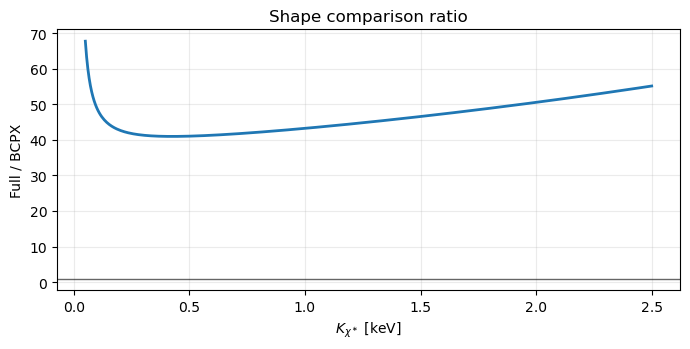

In [36]:
mchi_target_keV  = 3.7e3
delta_target_keV = 3.5
sigma_fig_cm2    = sigma_e_cm2  

K_full      = np.linspace(0.05, 2.5, 450)
dPhi_dK_full = np.array([dphi_dKstar_full(K, mchi_target_keV,
                                          delta_target_keV, sigma_fig_cm2, Nr=260)
                         for K in K_full])

K_bx        = K_full.copy()
dPhi_dK_bx  = flux_differential_core(K_bx, delta_target_keV)

# Optional shape matching
match = "none"   # choose "area", "peak", or "none"
if match == "area":
    scale = (trapz(dPhi_dK_full, K_full) + 1e-300) / (trapz(dPhi_dK_bx, K_bx) + 1e-300)
    dPhi_dK_bx_plot = dPhi_dK_bx * scale
elif match == "peak":
    scale = (np.max(dPhi_dK_full) + 1e-300) / (np.max(dPhi_dK_bx) + 1e-300)
    dPhi_dK_bx_plot = dPhi_dK_bx * scale
else:
    dPhi_dK_bx_plot = dPhi_dK_bx

# Overlay
plt.figure(figsize=(7.0,5.0))
plt.plot(K_full, dPhi_dK_full, lw=2.5, label="ANPPR (production $K_{\\chi^*}$)")
plt.plot(K_bx,   dPhi_dK_bx_plot, lw=2.0, ls="--",
         label=f"BBLW one-zone (scaled: {match})")
plt.xlabel(r"$K_{\chi^\ast}$ [keV]")
plt.ylabel(r"$d\Phi/dK_{\chi^\ast}$ [keV$^{-1}$ cm$^{-2}$ s$^{-1}$]")
plt.title(r"Solar thermal iDM: $m_\chi=3.7$ MeV, $\delta=3.5$ keV  (production spectrum)")
plt.legend(); plt.grid(alpha=0.25); plt.tight_layout(); plt.show()

# Ratio (Full / BCPX)
ratio = dPhi_dK_full / (dPhi_dK_bx_plot + 1e-300)
plt.figure(figsize=(7.0,3.6))
plt.plot(K_full, ratio, lw=2)
plt.axhline(1.0, color="k", lw=1, alpha=0.6)
plt.xlabel(r"$K_{\chi^\ast}$ [keV]")
plt.ylabel("Full / BCPX")
plt.title("Shape comparison ratio")
plt.grid(alpha=0.25); plt.tight_layout(); plt.show()